# Task 1 — Collaborative Filtering (MovieLens-100K)

(The dataset is MovieLens-100K, containing movie ratings from users.)

A) Memory-based collaborative filtering: User-User kNN (Find the users similar to the given user and predict thereafter)

B) Model-based collaborative filtering: Matrix Factorization (Learn hidden characteristics of users and movies, then use those characteristics to predict the ratings)




In [ ]:
import io, json, os, time, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42  # fixed to make the experiments reproducible
URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
print(np.__version__, pd.__version__)

# urllib.request - used to download the MovieLens dataset
# zipfile - lets python extract the downloaded .zip file

2.1.3 2.2.3


## 1. Data loading, splitting, matrix construction

In [ ]:
def load_movielens():
    """Returns a DataFrame with columns user, item, rating (0-indexed ids)."""
    folder = os.path.join(".", "ml-100k")
    if not os.path.exists(os.path.join(folder, "u.data")):
        print("Downloading MovieLens-100K ...")
        raw = urllib.request.urlopen(URL).read()
        zipfile.ZipFile(io.BytesIO(raw)).extractall(".")
    df = pd.read_csv(os.path.join(folder, "u.data"), sep="\t",
                     names=["user", "item", "rating", "ts"])
    df["user"] -= 1
    df["item"] -= 1
    return df[["user", "item", "rating"]]


def synthetic(n_users=300, n_items=200, n_ratings=20000, seed=0):
    rng = np.random.default_rng(seed)
    P, Q = rng.normal(size=(n_users, 4)), rng.normal(size=(n_items, 4))
    u = rng.integers(0, n_users, n_ratings)
    i = rng.integers(0, n_items, n_ratings)
    r = np.clip(np.round(3.5 + 0.6 * (P[u] * Q[i]).sum(1) + rng.normal(0, .3, n_ratings)), 1, 5)
    return pd.DataFrame({"user": u, "item": i, "rating": r}).drop_duplicates(["user", "item"])
# The synthetic dataset is included mainly for testing and debugging.
# It generates artificial user-item ratings with known latent factors, allowing us to check whether the collaborative filtering implementation works without depending on the real MovieLens dataset.
# In our actual experiment, USE_SYNTHETIC is false, so we use MovieLens-100K.

def split(df, seed=SEED):
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    # shuffle the dataset
    n = len(df)
    tr, va, te = df[: int(.8 * n)], df[int(.8 * n): int(.9 * n)], df[int(.9 * n):]
    # remove the users or movies not seenin the training split
    keep = lambda d: d[d.user.isin(tr.user) & d.item.isin(tr.item)]
    return tr, keep(va), keep(te)


def to_matrix(d, n_users, n_items):
    R = np.zeros((n_users, n_items))
    R[d.user.values, d.item.values] = d.rating.values
    return R, (R > 0).astype(float)
    # returns ratings, mask of observed entries
    keep = lambda d: d[d.user.isin(tr.user) & d.item.isin(tr.item)]
    return tr, keep(va), keep(te)


## 2. Metrics
RMSE/MAE, Precision/Recall

In [ ]:
def rmse(pred_matrix, d):
    e = pred_matrix[d.user.values, d.item.values] - d.rating.values
    return float(np.sqrt(np.mean(e ** 2)))


def mae(pred_matrix, d):
    return float(np.mean(np.abs(pred_matrix[d.user.values, d.item.values] - d.rating.values)))


def precision_recall_at_k(scores, seen_mask, test_df, k=10, thresh=4.0):
    n_users, n_items = scores.shape
    rel = np.zeros((n_users, n_items), dtype=bool)
    t = test_df[test_df.rating >= thresh]
    rel[t.user.values, t.item.values] = True
    s = scores.copy()
    s[seen_mask > 0] = -np.inf
    top = np.argpartition(-s, k, axis=1)[:, :k]
    hits = np.take_along_axis(rel, top, axis=1).sum(1)
    n_rel = rel.sum(1)
    ok = n_rel > 0                                     # only users that have relevant test items
    return float(np.mean(hits[ok] / k)), float(np.mean(hits[ok] / n_rel[ok]))

## 3. (A) Memory-based CF: user-user kNN
Prediction = user mean + (similarity-weighted opinion of neighbours)/(Total similarity)

* Numerator → collects the weighted deviations
* Denominator → normalizes those weights
* Numerator / denominator → gives the weighted average deviation
* +user's mean → converts the deviation back into an actual rating

#### 1. Why cosine similarity?
User A: [5, 4, 5, 4]
User B: [4, 3, 4, 3]

They have different rating scales.
But their pattern is similar:
high, medium, high, medium

Cosine similarity captures this pattern well.

#### 2. Why mean-centre the ratings?
Suppose:

User A: [5, 5, 4, 5]
User B: [3, 3, 2, 3]

User A gives high ratings to everything.

User B is more conservative.

But their preferences may actually be identical.

User A mean: 4.75
User B mean: 2.75

Subtract each user's mean.

A: +0.25 +0.25 -0.75 +0.25

B: +0.25 +0.25 -0.75 +0.25

Now they're identical.


In [ ]:
def user_knn_predict(R, M, k=40):
    cnt = M.sum(1)
    mean_u = R.sum(1) / np.maximum(cnt, 1)
    Rc = (R - mean_u.reshape(-1,1)) * M                       # centred, zeros where unobserved
    norm = np.linalg.norm(Rc, axis=1) + 1e-9
    S = (Rc @ Rc.T) / np.outer(norm, norm)
    np.fill_diagonal(S, 0)                                    # a user is not their own neighbour
    idx = np.argpartition(-S, k, axis=1)[:, :k]               # top-k most similar users per row
    rows = np.arange(S.shape[0]).reshape(-1,1)
    Sk = np.zeros_like(S)
    Sk[rows, idx] = S[rows, idx]
    Sk[Sk < 0] = 0                                            # keep positively correlated neighbours only
    num = Sk @ Rc                                             # sum_v sim * (r_vi - mean_v)   (0 if v has not rated i)
    den = Sk @ M + 1e-9                                       # sum_v sim over neighbours that rated i
    return np.clip(mean_u.reshape(-1,1) + num / den, 1, 5)    # no neighbour rated i -> falls back to user mean

## 4. (B) Model-based CF: matrix factorization

$r_{hat}(u,i)$ = $μ$ + $b_u$ + $b_i$ + $p_u$ · $q_i$

* $μ$ - Global average rating
* $b_u$ - User bias (How much higher or lower a user rates everything than the global average)
* $b_i$ - Movie bias (Maybe a movey is generall loved or hated)
* $p_u$ - Latent vector for user
* $q_i$ - latent vector for movie

Matrix factorization helps us represent the whole data as the dot product of two smaller matrices saving a lot of storage and making the prediction more accurate as well as it learns the underlying characteristics of users and movies.

SGD(stochastic gradient descent) where paraeters are updated after every training step

SGD advantages here
* Simple to implement
* Memory efficient
* Works naturally with sparse ratings
* Updates immediately
* Often converges well for matrix factorization

L2 regularization is used to prevent the bias from becoming unnecessarily large

In [ ]:
class BiasedMF:
    # k-number of latent features
    # lr-learning rate
    # reg-regularization strength
    def __init__(self, n_users, n_items, k=32, lr=0.01, reg=0.05, seed=SEED):
        rng = np.random.default_rng(seed)
        self.k, self.lr, self.reg = k, lr, reg
        self.P = rng.normal(0, 0.1, (n_users, k))        # small random init breaks symmetry
        self.Q = rng.normal(0, 0.1, (n_items, k))        # (mean, standard deviation, shape)
        self.bu, self.bi, self.mu = np.zeros(n_users), np.zeros(n_items), 0.0

    def full_matrix(self):
        return self.mu + self.bu.reshape(-1,1) + self.bi.reshape(1,-1) + self.P @ self.Q.T

    def fit(self, tr, va, epochs=30, verbose=True):
        u_all, i_all, r_all = tr.user.values, tr.item.values, tr.rating.values.astype(float)
        self.mu = r_all.mean()
        rng = np.random.default_rng(SEED)
        hist = {"train_rmse": [], "val_rmse": []}
        # store training RMSE and validation RMSE per epoch
        best = (1e9, None, -1)
        # (initialisation, model parameters, epoch)
        for ep in range(epochs):
            for j in rng.permutation(len(r_all)):
                u, i, r = u_all[j], i_all[j], r_all[j]
                pu, qi = self.P[u].copy(), self.Q[i].copy()
                e = r - (self.mu + self.bu[u] + self.bi[i] + pu @ qi)
                self.bu[u] += self.lr * (e - self.reg * self.bu[u])
                self.bi[i] += self.lr * (e - self.reg * self.bi[i])
                self.P[u] += self.lr * (e * qi - self.reg * pu)
                self.Q[i] += self.lr * (e * pu - self.reg * qi)
            F = np.clip(self.full_matrix(), 1, 5)
            tr_e, va_e = rmse(F, tr), rmse(F, va)
            hist["train_rmse"].append(tr_e); hist["val_rmse"].append(va_e)
            if va_e < best[0]:
                best = (va_e, (self.P.copy(), self.Q.copy(), self.bu.copy(), self.bi.copy()), ep)
            if verbose and (ep % 5 == 0 or ep == epochs - 1):
                print(f"   epoch {ep+1:3d}  train RMSE {tr_e:.4f}  val RMSE {va_e:.4f}")

        self.P, self.Q, self.bu, self.bi = best[1]
        return hist, best[0], best[2] + 1

## 5. Experiment
### 5.1 Config, load, split, explore

users=943 items=1682 ratings=100000 | train=80000 val=9986 test=9978 | density=6.305%


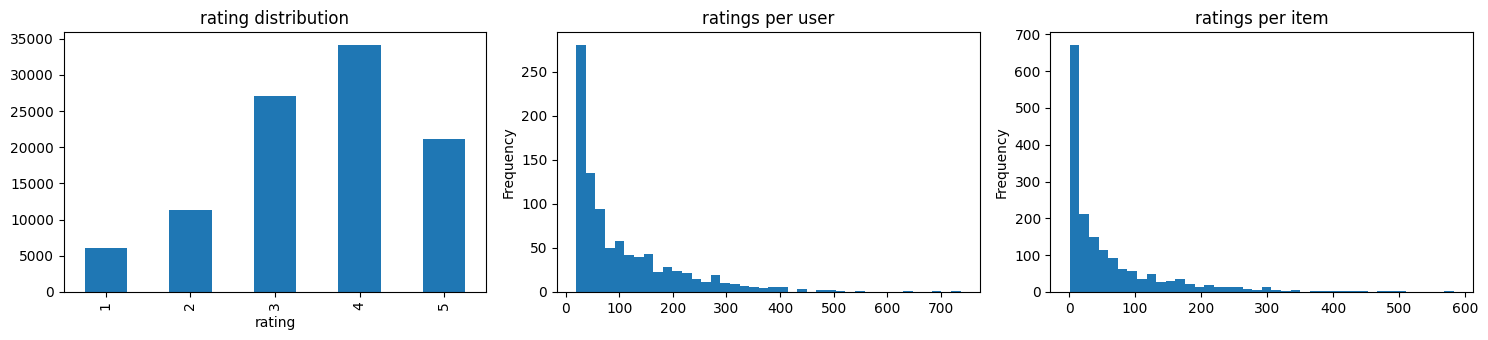

In [ ]:
USE_SYNTHETIC = False     # True = tiny fake data (fast smoke test)
EPOCHS = 30
K_FACTORS = 32
# Hyperparameters

np.random.seed(SEED)
df = synthetic() if USE_SYNTHETIC else load_movielens()
df = df.assign(user=pd.factorize(df.user)[0], item=pd.factorize(df.item)[0])
n_users, n_items = df.user.max() + 1, df.item.max() + 1
tr, va, te = split(df)
print(f"users={n_users} items={n_items} ratings={len(df)} | train={len(tr)} val={len(va)} test={len(te)}"
      f" | density={len(df)/(n_users*n_items):.3%}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
df.rating.value_counts().sort_index().plot.bar(ax=ax[0], title="rating distribution")
df.groupby("user").size().plot.hist(bins=40, ax=ax[1], title="ratings per user")
df.groupby("item").size().plot.hist(bins=40, ax=ax[2], title="ratings per item")
plt.tight_layout(); plt.show()

### 5.2 Baselines (context for the numbers)

Suppose your sophisticated neural network gives: RMSE = 1.1

but global mean gives: RMSE = 1.0

Then your complicated model isn't helping. Baselines provide context.

In [ ]:
R_tr, M_tr = to_matrix(tr, n_users, n_items)
seen = to_matrix(pd.concat([tr, va]), n_users, n_items)[1]      # items excluded from the top-N candidate list
res = {}

gm = np.full((n_users, n_items), tr.rating.mean())
res["GlobalMean"] = dict(rmse=rmse(gm, te), mae=mae(gm, te), p10=np.nan, r10=np.nan)

pop = np.tile(M_tr.sum(0), (n_users, 1))                         # most-rated items first, same for everyone
p, r = precision_recall_at_k(pop, seen, te)
res["Popularity"] = dict(rmse=np.nan, mae=np.nan, p10=p, r10=r)
pd.DataFrame(res).T.round(4)

,rmse,mae,p10,r10
GlobalMean,1.1332,0.9504,NaN,NaN
Popularity,NaN,NaN,0.077,0.1387


### 5.3 (A) choose k on the validation set

k=   5  val RMSE 1.0670
k=  10  val RMSE 1.0407
k=  20  val RMSE 1.0057
k=  40  val RMSE 0.9729
k=  80  val RMSE 0.9472
k= 160  val RMSE 0.9350


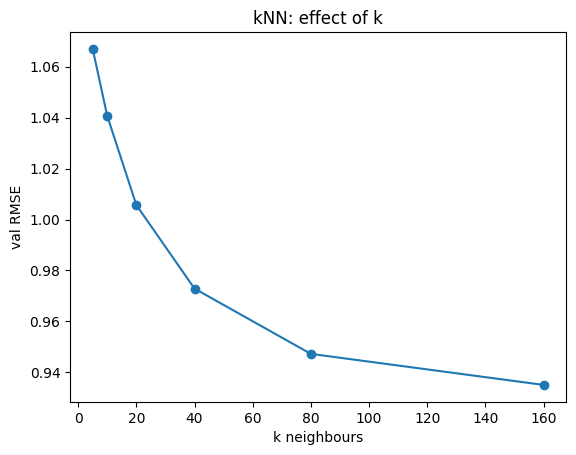

In [ ]:
ks = [k for k in [5, 10, 20, 40, 80, 160] if k < n_users]
# k is a hypeparameter
knn_val = []
for k in ks:
    knn_val.append(rmse(user_knn_predict(R_tr, M_tr, k), va))
    print(f"k={k:4d}  val RMSE {knn_val[-1]:.4f}")
k_best = ks[int(np.argmin(knn_val))]

t0 = time.time()
P_knn = user_knn_predict(R_tr, M_tr, k_best)
t_knn = time.time() - t0
p, r = precision_recall_at_k(P_knn, seen, te)
res[f"UserKNN(k={k_best})"] = dict(rmse=rmse(P_knn, te), mae=mae(P_knn, te), p10=p, r10=r, seconds=t_knn)

plt.plot(ks, knn_val, "o-"); plt.xlabel("k neighbours"); plt.ylabel("val RMSE"); plt.title("kNN: effect of k"); plt.show()

### 5.4 (B) choose regularisation (and best epoch) on the validation set


reg=0.02
   epoch   1  train RMSE 0.9610  val RMSE 0.9761
   epoch   6  train RMSE 0.8836  val RMSE 0.9377
   epoch  11  train RMSE 0.7966  val RMSE 0.9249
   epoch  16  train RMSE 0.6960  val RMSE 0.9324
   epoch  21  train RMSE 0.6175  val RMSE 0.9506
   epoch  26  train RMSE 0.5634  val RMSE 0.9671
   epoch  30  train RMSE 0.5326  val RMSE 0.9795
  -> best val RMSE 0.9249 at epoch 11 (49s)
reg=0.05
   epoch   1  train RMSE 0.9621  val RMSE 0.9766
   epoch   6  train RMSE 0.8976  val RMSE 0.9384
   epoch  11  train RMSE 0.8494  val RMSE 0.9246
   epoch  16  train RMSE 0.7810  val RMSE 0.9162
   epoch  21  train RMSE 0.7148  val RMSE 0.9164
   epoch  26  train RMSE 0.6610  val RMSE 0.9205
   epoch  30  train RMSE 0.6278  val RMSE 0.9264
  -> best val RMSE 0.9149 at epoch 19 (46s)
reg=0.1
   epoch   1  train RMSE 0.9640  val RMSE 0.9777
   epoch   6  train RMSE 0.9115  val RMSE 0.9407
   epoch  11  train RMSE 0.8955  val RMSE 0.9327
   epoch  16  train RMSE 0.8717  val RMSE 0.9247
   e

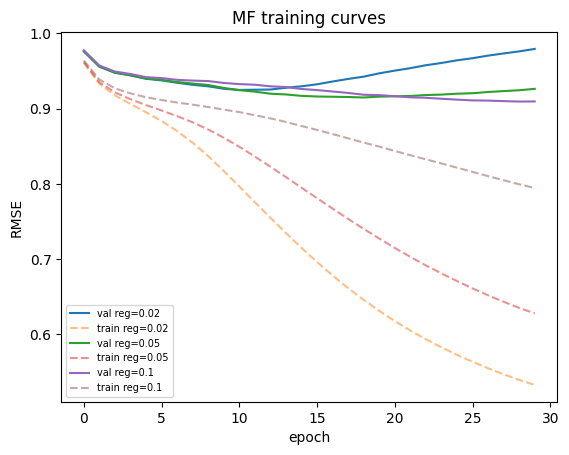

In [ ]:
best_mf, curves = None, {}
for reg in [0.02, 0.05, 0.1]:
    print(f"reg={reg}")
    mf = BiasedMF(n_users, n_items, k=K_FACTORS, reg=reg)
    t0 = time.time()
    hist, v, ep = mf.fit(tr, va, epochs=EPOCHS)
    curves[reg] = hist
    print(f"  -> best val RMSE {v:.4f} at epoch {ep} ({time.time()-t0:.0f}s)")
    if best_mf is None or v < best_mf[0]:
        best_mf = (v, reg, ep, mf, time.time() - t0)

_, reg_best, ep_best, mf, t_mf = best_mf
F = np.clip(mf.full_matrix(), 1, 5)
p, r = precision_recall_at_k(mf.full_matrix(), seen, te)          # rank with un-clipped scores (avoids ties at 5.0)
res[f"MF(k={K_FACTORS},reg={reg_best})"] = dict(rmse=rmse(F, te), mae=mae(F, te), p10=p, r10=r, seconds=t_mf)

for reg, h in curves.items():
    plt.plot(h["val_rmse"], label=f"val reg={reg}"); plt.plot(h["train_rmse"], "--", alpha=.5, label=f"train reg={reg}")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.title("MF training curves"); plt.legend(fontsize=7); plt.show()

### 5.5 Final test results

TEST (lower RMSE/MAE better, higher P@10/R@10 better)


,rmse,mae,p10,r10
GlobalMean,1.1332,0.9504,NaN,NaN
Popularity,NaN,NaN,0.0770,0.1387
UserKNN(k=160),0.9452,0.7351,0.0016,0.0033
"MF(k=32,reg=0.1)",0.9173,0.7244,0.0397,0.0535


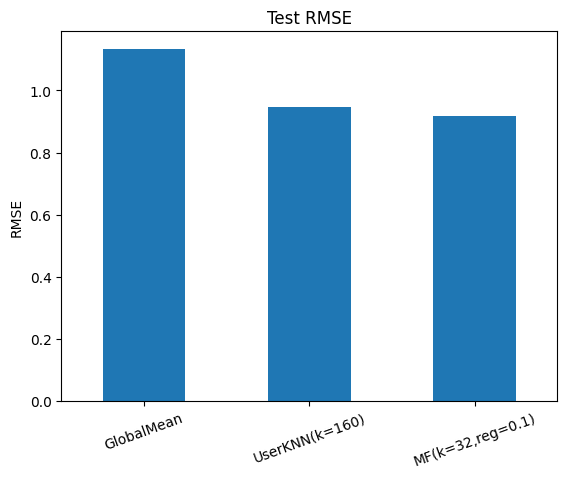

In [ ]:
table = pd.DataFrame(res).T[["rmse", "mae", "p10", "r10"]].round(4)
print("TEST (lower RMSE/MAE better, higher P@10/R@10 better)")
display(table)
table["rmse"].dropna().plot.bar(rot=20, title="Test RMSE"); plt.ylabel("RMSE"); plt.show()
table.to_csv("results_cf.csv")

## 6. Conclusion

### Approach 1 : User kNN
* User × Movie ratings
* Mean-center each user's ratings
* Calculate cosine similarity
* Find k nearest users
* Look at what similar users liked
* Predict rating

### Approach 2 : Matrix Factorization
* User × Movie ratings
* Initialize:
    + User latent vectors
    + Movie latent vectors
    + User biases
    + Movie biases
* Predict rating:
$$ \hat r_{ui} = \mu+b_u+b_i+p_uq_i $$
* Calculate error:
$$ e=r-\hat r $$
* Use SGD
* Update parameters
* Repeat over epochs
* Use validation set to choose regularization/best epoch
* Evaluate once on test set.

Therefore, to conclude:

Matrix Factorization performed best for rating prediction, achieving the lowest RMSE and MAE. For top-10 recommendations, the Popularity baseline achieved higher Precision@10 and Recall@10 than MF and User-KNN on this test set

